In [1]:
pip install transformers torch

Note: you may need to restart the kernel to use updated packages.


Loading weights: 100%|██████████| 434/434 [00:00<00:00, 630.26it/s, Materializing param=model.norm.weight]                              


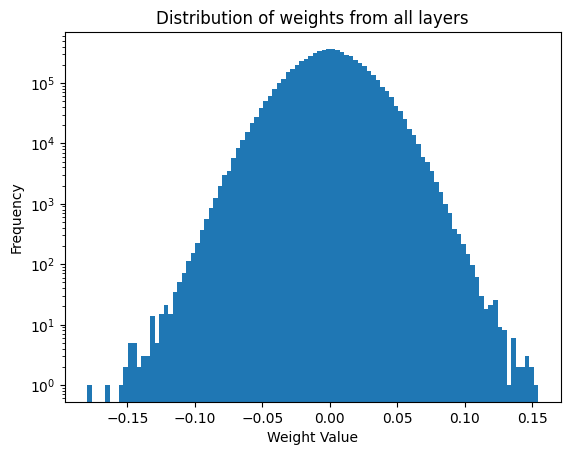

In [ ]:
from typing import List

import numpy as np
from torch import Tensor
from transformers import AutoTokenizer, AutoModelForCausalLM
from dotenv import load_dotenv
import os
import matplotlib.pyplot as plt

load_dotenv()


class ModelLayer():
    def __init__(self, layer_name: str, layer_data: Tensor) -> None:
        self.layer_name = layer_name
        self.layer_data = layer_data
        
    def get_weights(self) -> np.ndarray:
        weights = self.layer_data.data.flatten().float().numpy()
        return weights
        

class Model():
    def __init__(self, model_name: str) -> None:
        self.model_name = model_name
        self.tokenizer = None
        self.model = None
        self.layers: List[ModelLayer] = []
        
    def load_model(self, token: str) -> None:
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, token=token)
        self.model = AutoModelForCausalLM.from_pretrained(self.model_name, token=token)
        self.model.eval()
        
        self.layers: List[ModelLayer] = []
        for name, param in self.model.named_parameters():
            layer = ModelLayer(name, param)
            self.layers.append(layer)
            
class Analyzer():
    def __init__(self, model: Model) -> None:
        self.model = model
        
    def collect_weights(self) -> None:
        self.weights: np.ndarray | None = None
        
        for layer in self.model.layers:
            layer_weights = layer.get_weights()
            if self.weights is None:
                self.weights = layer_weights
            else:
                self.weights = np.concatenate((self.weights, layer_weights))
                
        if self.weights is None:
            raise Exception("Failed to collect weights from layers")
        
    def show_all_distribution(self, reduction: float, log_y: bool = False, log_x: bool = False) -> None:
        if not 0 < reduction <= 1:
            raise ValueError("Reduction must be in the interval (0, 1].")
        
        if self.weights is None:
            raise Exception("Weights not collected. Operation aborted.")
        
        target_size = max(1, int(len(self.weights) * reduction))
        indices = np.random.choice(len(self.weights), size=target_size, replace=False)
        weights = self.weights[indices]
        
        plt.figure()
        plt.hist(weights, bins=100)
        plt.title("Distribution of weights from all layers")
        plt.xlabel("Weight Value")
        plt.ylabel("Frequency")
        if log_y:
            plt.yscale("log")
        if log_x:
            plt.xscale("log")
        plt.show()
    
model_name = "Qwen/Qwen2.5-3B-Instruct"

token = os.environ.get("HF_TOKEN")

if token is None:
    raise Exception("Token for HuggingFace is not set")
    
model = Model("Qwen/Qwen2.5-3B-Instruct")
model.load_model(token)
analyzer = Analyzer(model)
analyzer.collect_weights()
analyzer.show_all_distribution(0.01, log_y=True, log_x=False)